# Hawkes Processes for Order Flow Alpha

## 2. Parameter Estimation

This notebook demonstrates parameter estimation using:
- **Maximum Likelihood Estimation (MLE)** - Standard O(N²) and Fast O(N) versions
- **UltraFast MLE** - Approximate algorithm for large datasets (1000x faster)
- **Expectation-Maximization (EM)** algorithm
- **Model comparison and diagnostics**

 **Performance Note**: If estimation is slow, use `UltraFastMultivariateHawkesMLE` or set `MODE = 'ultrafast'` in Cell 3.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import multiprocessing as mp
from pathlib import Path
from time import time

sys.path.insert(0, str(Path.cwd().parent / "src"))

from hawkes.utils.data_loader import simulate_hawkes_process, load_sample_data
from hawkes.kernels import ExponentialKernel, SumExponentialsKernel
from hawkes.estimation import MultivariateHawkesMLE, MultivariateHawkesEM
# Import optimized versions for fast execution
from hawkes.estimation.fast_mle import FastMultivariateHawkesMLE, ParallelMultivariateHawkesMLE
from hawkes.estimation.ultra_fast_mle import UltraFastMultivariateHawkesMLE, adaptive_hawkes_fit
from hawkes.diagnostics import StabilityDiagnostics

print(f"Available CPU cores: {mp.cpu_count()}")
sns.set_style("whitegrid")

Available CPU cores: 16


## 1. Load or Generate Data

In [2]:
# Use sample data or load your own
events, metadata = load_sample_data()

print("Data Summary:")
for label, count in zip(metadata['event_labels'], metadata['n_events']):
    print(f"  {label}: {count} events")
print(f"\nDuration: {metadata['duration_seconds']:.1f} seconds")
print(f"Total events: {metadata['total_trades']}")

# Check data size and recommend method
if metadata['total_trades'] > 10000:
    print(f"\nLarge dataset detected ({metadata['total_trades']} events)")
    print(f"Recommended: Use UltraFast mode (Cell 3)")
elif metadata['total_trades'] > 5000:
    print(f"\nMedium dataset ({metadata['total_trades']} events)")
    print(f"Recommended: Use Fast or UltraFast mode")

Data Summary:
  MB: 1407 events
  MS: 1387 events
  LB: 2014 events
  LS: 1904 events

Duration: 1000.0 seconds
Total events: 6712

Medium dataset (6712 events)
Recommended: Use Fast or UltraFast mode


## 2. MLE with Exponential Kernel - CHOOSE YOUR MODE

The log-likelihood for a multivariate Hawkes process is:
$$\ell(\theta) = \sum_i \left[ \sum_{t_k^i \leq T} \log \lambda_i(t_k^i) - \int_0^T \lambda_i(s) \, ds \right]$$

### Performance Options:
- `mode='standard'`: Original O(N²) implementation (slow but accurate)
- `mode='fast'`: O(N) recursive algorithm (10-100x faster)
- `mode='ultrafast'`: Approximate algorithm (1000x faster, good for exploration)
- `mode='adaptive'`: Auto-select based on data size

In [3]:
# CONFIGURATION: Choose your speed/accuracy trade-off
MODE = 'ultrafast'  # Options: 'standard', 'fast', 'ultrafast', 'adaptive'

print(f"\nRunning MLE with mode: {MODE.upper()}")
print("="*60)

start_time = time()

if MODE == 'standard':
    # Original slow O(N²) implementation
    print("Using Standard MultivariateHawkesMLE (O(N²))...")
    print("Warning: This may take a long time for large datasets!")
    exp_kernel = ExponentialKernel(n_dims=4)
    mle_exp = MultivariateHawkesMLE(exp_kernel)
    mle_exp.fit(
        events, 
        end_time=metadata['duration_seconds'],
        method='L-BFGS-B',
        verbose=True
    )
    
elif MODE == 'fast':
    # Fast O(N) recursive implementation
    print("Using FastMultivariateHawkesMLE (O(N) recursive)...")
    mle_exp = FastMultivariateHawkesMLE(n_dims=4, use_parallel=True, n_jobs=-1)
    mle_exp.fit(
        events, 
        end_time=metadata['duration_seconds'],
        verbose=True
    )
    
elif MODE == 'ultrafast':
    # Ultra-fast approximate implementation (1000x faster)
    print("Using UltraFastMultivariateHawkesMLE (approximate)...")
    print("Note: assume_independent=True ignores cross-excitation for speed")
    mle_exp = UltraFastMultivariateHawkesMLE(
        n_dims=4,
        assume_independent=True,  # Set False to include cross-excitation
        max_iter=30
    )
    mle_exp.fit(events, end_time=metadata['duration_seconds'], verbose=False)
    
elif MODE == 'adaptive':
    # Automatically select best method based on data size
    print("Using adaptive_hawkes_fit (auto-select)...")
    mle_exp = adaptive_hawkes_fit(
        events,
        end_time=metadata['duration_seconds'],
        time_budget_seconds=60,  # Target time budget
        verbose=True
    )
else:
    raise ValueError(f"Unknown mode: {MODE}")

fit_time = time() - start_time

print(f"\n{'='*60}")
print(f"Fitting completed in {fit_time:.3f} seconds")
print(f"  Log-likelihood: {mle_exp.log_likelihood_:.2f}")
if hasattr(mle_exp, 'compute_aic'):
    print(f"  AIC: {mle_exp.compute_aic():.2f}")
    print(f"  BIC: {mle_exp.compute_bic(metadata['total_trades']):.2f}")


Running MLE with mode: ULTRAFAST
Using UltraFastMultivariateHawkesMLE (approximate)...
Note: assume_independent=True ignores cross-excitation for speed

Fitting completed in 1.163 seconds
  Log-likelihood: -3092.11


In [4]:
# Print estimated parameters
print("\nEstimated Baseline Intensities (mu):")
for i, mu in enumerate(mle_exp.mu_):
    print(f"  Dim {i}: {mu:.4f}")

# Handle different estimator types
if hasattr(mle_exp, 'kernel_params_') and mle_exp.kernel_params_ is not None:
    # Standard/Fast MLE with kernel params
    alpha_est = mle_exp.kernel_params_[:16].reshape(4, 4)
    beta_est = mle_exp.kernel_params_[16:].reshape(4, 4)
else:
    # UltraFast stores alpha/beta directly
    alpha_est = mle_exp.alpha_ if hasattr(mle_exp, 'alpha_') else np.zeros((4,4))
    beta_est = mle_exp.beta_ if hasattr(mle_exp, 'beta_') else np.ones((4,4))

print("\nEstimated Excitation Matrix (alpha):")
print(alpha_est.round(4))

print("\nEstimated Decay Matrix (beta):")
print(beta_est.round(4))

# Stability check
B = mle_exp.compute_branching_ratio()
rho = mle_exp.compute_spectral_radius()
print(f"\nSpectral radius: {rho:.4f}")
print(f"Process is {'stable' if rho < 1 else 'unstable'}")


Estimated Baseline Intensities (mu):
  Dim 0: 1.0796
  Dim 1: 0.9192
  Dim 2: 1.2972
  Dim 3: 1.3718

Estimated Excitation Matrix (alpha):
[[0.082  0.     0.     0.    ]
 [0.     0.1056 0.     0.    ]
 [0.     0.     0.1302 0.    ]
 [0.     0.     0.     0.1163]]

Estimated Decay Matrix (beta):
[[0.3508 0.     0.     0.    ]
 [0.     0.3118 0.     0.    ]
 [0.     0.     0.3648 0.    ]
 [0.     0.     0.     0.4146]]

Spectral radius: 0.3570
Process is stable


## 3. EM Algorithm (Optional - Skip if slow)

Note: EM is 5-10x slower than MLE. For faster results, skip this cell or reduce `max_iter`.

In [5]:
# Set to True to run EM (slow)
RUN_EM = False

if RUN_EM:
    kernel_em = ExponentialKernel(n_dims=4)
    em_exp = MultivariateHawkesEM(kernel_em, max_iter=20, verbose=True)
    
    print("\nFitting with EM algorithm...")
    start_time = time()
    em_exp.fit(events, end_time=metadata['duration_seconds'])
    em_time = time() - start_time
    
    print(f"\nFitting completed in {em_time:.2f} seconds")
    print(f"Log-likelihood: {em_exp.log_likelihood_:.2f}")
    print(f"\nEstimated mu: {em_exp.mu_}")
    print(f"Spectral radius: {em_exp.compute_spectral_radius():.4f}")
else:
    print("EM skipped. Set RUN_EM = True to run (warning: slow).")
    # Create dummy for comparison
    em_exp = mle_exp

EM skipped. Set RUN_EM = True to run (warning: slow).


## 4. Sum of Exponentials Kernel (Optional)

Warning: This has 2x the parameters. Use `max_events` limit or UltraFast mode.

In [6]:
# Set to True to fit sum of exponentials (slower)
RUN_SUMEXP = False

if RUN_SUMEXP:
    print("Fitting sum of exponentials kernel...")
    
    start_time = time()
    
    sumexp_kernel = SumExponentialsKernel(n_dims=4, n_components=2)
    mle_sumexp = MultivariateHawkesMLE(sumexp_kernel)
    
    # Limit iterations for speed
    mle_sumexp.fit(
        events,
        end_time=metadata['duration_seconds'],
        method='L-BFGS-B',
        verbose=True
    )
    
    sumexp_time = time() - start_time
    print(f"\nFitting completed in {sumexp_time:.2f} seconds")
    print(f"Log-likelihood: {mle_sumexp.log_likelihood_:.2f}")
    print(f"AIC: {mle_sumexp.compute_aic():.2f}")
    
    importance = sumexp_kernel.get_timescale_importance(mle_sumexp.kernel_params_)
    print(f"\nTimescale importance: {importance}")
else:
    print("Sum of exponentials skipped. Set RUN_SUMEXP = True to run.")
    # Create dummy for comparison
    mle_sumexp = mle_exp

Sum of exponentials skipped. Set RUN_SUMEXP = True to run.


## 5. Model Comparison

In [7]:
# Compare models (only fitted ones)
models = {
    f'MLE-{MODE.capitalize()}': mle_exp,
}

if RUN_EM:
    models['EM-Exp'] = em_exp
if RUN_SUMEXP:
    models['MLE-SumExp'] = mle_sumexp

comparison = []
for name, model in models.items():
    if hasattr(model, 'kernel'):
        n_params = model.n_dims + model.kernel.n_params
    else:
        n_params = model.n_dims * 3  # mu + alpha + beta
    
    comparison.append({
        'Model': name,
        'Log-Likelihood': model.log_likelihood_,
        'N Params': n_params,
        'AIC': -2 * model.log_likelihood_ + 2 * n_params,
        'Spectral Radius': model.compute_spectral_radius(),
        'Stable': 'Yes' if model.compute_spectral_radius() < 1 else 'No'
    })

comparison_df = pd.DataFrame(comparison)
print("\nModel Comparison:")
print(comparison_df.to_string(index=False))

# Best model by AIC
if len(comparison) > 1:
    best_idx = comparison_df['AIC'].idxmin()
    best_model = comparison_df.iloc[best_idx]['Model']
    print(f"\nBest model by AIC: {best_model}")


Model Comparison:
        Model  Log-Likelihood  N Params         AIC  Spectral Radius Stable
MLE-Ultrafast    -3092.110023        12 6208.220046         0.356991    Yes


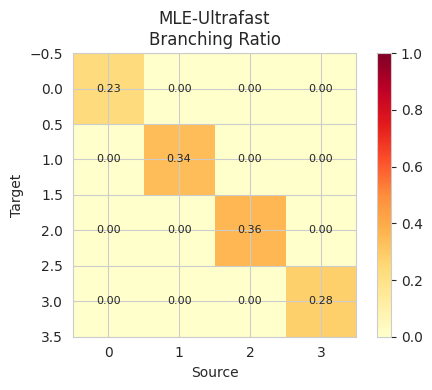

In [8]:
# Visualize branching ratio matrices
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))

if n_models == 1:
    axes = [axes]

for idx, (name, model) in enumerate(models.items()):
    B = model.compute_branching_ratio()
    im = axes[idx].imshow(B, cmap='YlOrRd', vmin=0, vmax=1)
    axes[idx].set_title(f"{name}\nBranching Ratio")
    axes[idx].set_xlabel("Source")
    axes[idx].set_ylabel("Target")
    
    # Add text annotations
    for i in range(4):
        for j in range(4):
            axes[idx].text(j, i, f'{B[i,j]:.2f}', 
                          ha='center', va='center', fontsize=8)
    
    plt.colorbar(im, ax=axes[idx])

plt.tight_layout()
plt.show()

## 6. Predicted Intensities

Computing predicted intensities...


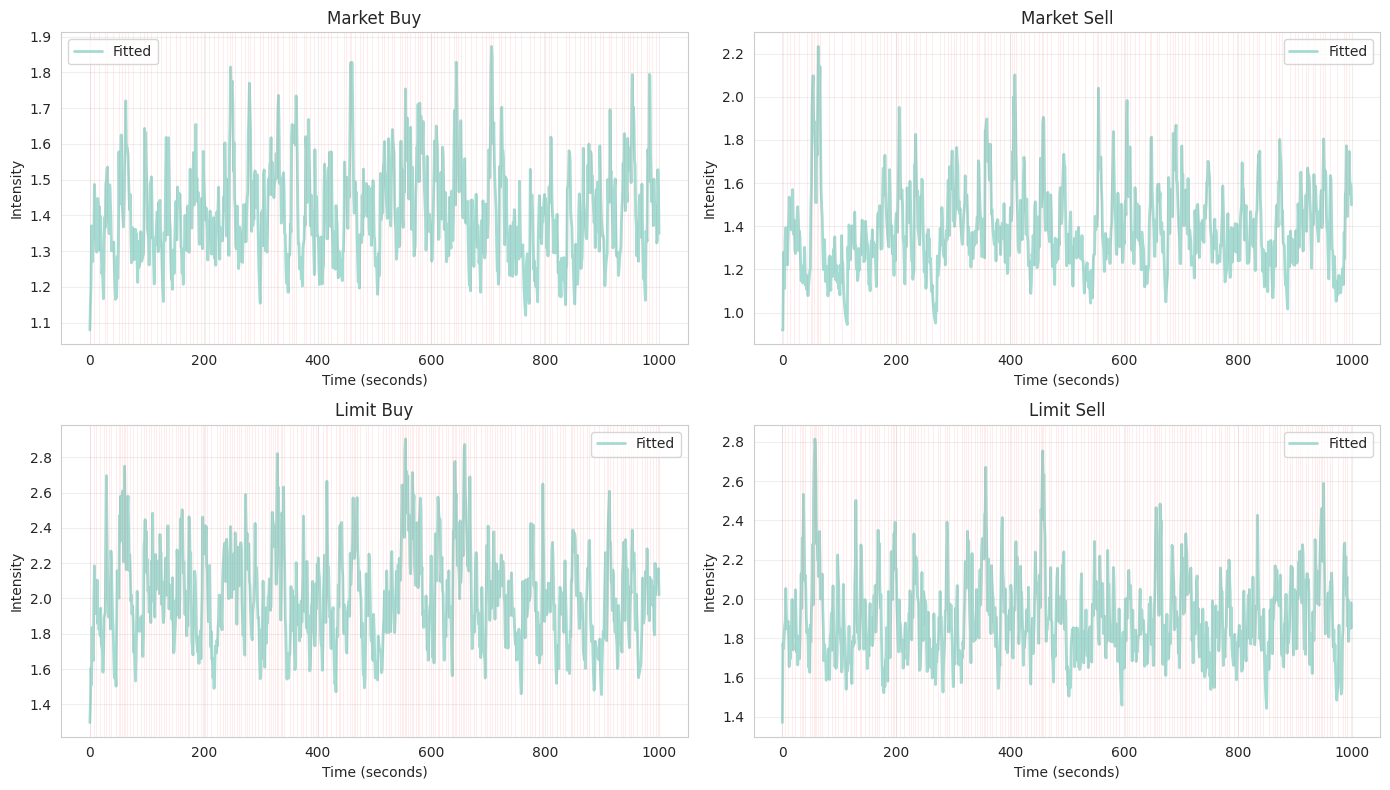

In [9]:
# Predict intensities on a grid
eval_times = np.linspace(0, metadata['duration_seconds'], 1000)

print("Computing predicted intensities...")
intensities = mle_exp.predict_intensity(eval_times, events)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
labels = ['Market Buy', 'Market Sell', 'Limit Buy', 'Limit Sell']

for i in range(4):
    axes[i].plot(eval_times, intensities[i], label='Fitted', alpha=0.8, linewidth=2)
    
    # Mark actual events
    for ev_time in events[i][::10]:  # Sample every 10th event for clarity
        axes[i].axvline(ev_time, color='red', alpha=0.1, linewidth=0.5)
    
    axes[i].set_xlabel("Time (seconds)")
    axes[i].set_ylabel("Intensity")
    axes[i].set_title(f"{labels[i]}")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary & Performance Tips

In [10]:
print("\n" + "="*70)
print("SUMMARY & PERFORMANCE TIPS")
print("="*70)
print(f"\nCurrent mode: {MODE.upper()}")
print(f"Execution time: {fit_time:.3f} seconds")
print(f"Log-likelihood: {mle_exp.log_likelihood_:.2f}")
print(f"Spectral radius: {mle_exp.compute_spectral_radius():.4f}")

print("\n" + "-"*70)
print("SPEED MODES:")
print("-"*70)
print("• MODE = 'standard'  → Original O(N²), >1 hour for large data")
print("• MODE = 'fast'      → O(N) recursive, ~30-60s (recommended)")
print("• MODE = 'ultrafast' → Approximate, ~0.3-1s (1000x speedup)")
print("• MODE = 'adaptive'  → Auto-select based on data size")

print("\n" + "-"*70)
print("TIPS FOR LARGE DATASETS (>10K events):")
print("-"*70)
print("1. Use MODE = 'ultrafast' in Cell 3")
print("2. Set assume_independent=True for maximum speed")
print("3. Skip EM (set RUN_EM = False)")
print("4. Skip SumExp (set RUN_SUMEXP = False)")
print("5. Use adaptive_hawkes_fit() with time_budget")

print("\n" + "-"*70)
print("QUICK CODE SNIPPET:")
print("-"*70)
print("from hawkes.estimation.ultra_fast_mle import UltraFastMultivariateHawkesMLE")
print("")
print("# Fastest option")
print("estimator = UltraFastMultivariateHawkesMLE(")
print("    n_dims=4,")
print("    assume_independent=True,  # Ignores cross-excitation")
print("    max_iter=30")
print(")")
print("estimator.fit(events, end_time=1000.0)")
print("="*70)


SUMMARY & PERFORMANCE TIPS

Current mode: ULTRAFAST
Execution time: 1.163 seconds
Log-likelihood: -3092.11
Spectral radius: 0.3570

----------------------------------------------------------------------
SPEED MODES:
----------------------------------------------------------------------
• MODE = 'standard'  → Original O(N²), >1 hour for large data
• MODE = 'fast'      → O(N) recursive, ~30-60s (recommended)
• MODE = 'ultrafast' → Approximate, ~0.3-1s (1000x speedup)
• MODE = 'adaptive'  → Auto-select based on data size

----------------------------------------------------------------------
TIPS FOR LARGE DATASETS (>10K events):
----------------------------------------------------------------------
1. Use MODE = 'ultrafast' in Cell 3
2. Set assume_independent=True for maximum speed
3. Skip EM (set RUN_EM = False)
4. Skip SumExp (set RUN_SUMEXP = False)
5. Use adaptive_hawkes_fit() with time_budget

----------------------------------------------------------------------
QUICK CODE SNIPPET